# 01b L1B Sweep Tx/Rx Matrix

Purpose:
- read one specified CASALS L1B H5 file;
- extract one specified sweep using explicit `sweep_num` and `track_num`;
- assemble the selected sweep into track-ordered `tx_matrix` and `rx_matrix`;
- diagnose how raw RX argmax behavior relates to the official `refh` fields.

Scientific boundary:
- this notebook organizes waveform matrices by sweep and track;
- `raw_rx_argmax_bin_by_track` is a diagnostic derived from the raw RX waveform, not a new geolocation product;
- secondary waveform peaks are waveform-derived components only and are not georeferenced returns in this notebook;
- this notebook does not create an official multi-return point cloud.

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_casals_l1b_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "waveform_components.py").exists():
            return candidate
        if (candidate / "CASALS_L1B" / "waveform_components.py").exists():
            return candidate / "CASALS_L1B"
    raise FileNotFoundError("Could not locate CASALS_L1B directory from the current notebook working directory.")


CASALS_L1B_DIR = find_casals_l1b_root()
if str(CASALS_L1B_DIR) not in sys.path:
    sys.path.insert(0, str(CASALS_L1B_DIR))

from waveform_components import (
    build_record_index_grid,
    infer_waveform_record_axis,
    read_optional_1d,
    read_waveform_records,
    require_dataset,
    safe_argmax_bin,
)

%matplotlib inline

H5_PATH = CASALS_L1B_DIR / "casals_h5_downloads" / "casals_l1b_20241118T171757_001_02.h5"
SWEEP_IDX = 5000
DISPLAY_TRACKS = 256
RX_VMIN = None
RX_VMAX = None

assert H5_PATH.exists(), H5_PATH

In [2]:
with h5py.File(H5_PATH, "r") as h5:
    info = build_record_index_grid(h5)
    tx_ds = require_dataset(h5, "tx_waveform")
    rx_ds = require_dataset(h5, "rx_waveform")
    rx_bins = np.asarray(require_dataset(h5, "rx_bins")[...], dtype=np.int64)
    tx_bins = np.asarray(require_dataset(h5, "tx_bins")[...], dtype=np.int64)

    rx_record_axis = infer_waveform_record_axis(rx_ds, info.n_records)
    tx_record_axis = infer_waveform_record_axis(tx_ds, info.n_records)

    if SWEEP_IDX < 0 or SWEEP_IDX >= info.n_sweeps:
        raise ValueError(f"SWEEP_IDX={SWEEP_IDX} is out of range for n_sweeps={info.n_sweeps}")

    selected_tracks = np.arange(min(DISPLAY_TRACKS, info.n_tracks), dtype=np.int64)
    record_indices = info.record_index_grid[SWEEP_IDX, selected_tracks]
    valid_mask = record_indices >= 0
    valid_tracks = selected_tracks[valid_mask]
    valid_indices = record_indices[valid_mask]

    n_tx_bins = int(tx_ds.shape[1] if tx_record_axis == 0 else tx_ds.shape[0])
    n_rx_bins = int(rx_ds.shape[1] if rx_record_axis == 0 else rx_ds.shape[0])
    tx_matrix = np.full((selected_tracks.size, n_tx_bins), np.nan, dtype=np.float32)
    rx_matrix = np.full((selected_tracks.size, n_rx_bins), np.nan, dtype=np.float32)
    if valid_indices.size:
        tx_matrix[valid_mask] = read_waveform_records(tx_ds, tx_record_axis, valid_indices)
        rx_matrix[valid_mask] = read_waveform_records(rx_ds, rx_record_axis, valid_indices)

    pulse_fields = {}
    for name, dtype in [
        ("refh", np.float64),
        ("refh_longitude", np.float64),
        ("refh_latitude", np.float64),
        ("refh_amp", np.float64),
        ("refh_snr", np.float64),
        ("good_snr", bool),
        ("bg_mean", np.float64),
        ("bg_std", np.float64),
        ("refh_thres", np.float64),
        ("rwstart", np.float64),
        ("rwstop", np.float64),
        ("local_beam_azimuth", np.float64),
        ("local_beam_elevation", np.float64),
    ]:
        pulse_fields[name] = read_optional_1d(h5, name, info.n_records, dtype=dtype)

sweep_df = pd.DataFrame({"track_num": selected_tracks})
sweep_df["pulse_index"] = info.record_index_grid[SWEEP_IDX, selected_tracks]
sweep_df["has_waveform"] = sweep_df["pulse_index"] >= 0

for name, arr in pulse_fields.items():
    values = np.full(selected_tracks.size, np.nan if name != "good_snr" else False, dtype=object if name == "good_snr" else np.float64)
    if arr is not None:
        valid_values = arr[valid_indices]
        values[valid_mask] = valid_values
    sweep_df[name] = values

raw_rx_argmax_bin_by_track = np.full(selected_tracks.size, np.nan, dtype=np.float64)
raw_rx_argmax_amp_by_track = np.full(selected_tracks.size, np.nan, dtype=np.float64)
bg_subtracted_rx_matrix = np.full_like(rx_matrix, np.nan, dtype=np.float32)
bg_subtracted_argmax_bin_by_track = np.full(selected_tracks.size, np.nan, dtype=np.float64)
tx_argmax_bin_by_track = np.full(selected_tracks.size, np.nan, dtype=np.float64)

for i in range(selected_tracks.size):
    raw_rx_argmax_bin_by_track[i], raw_rx_argmax_amp_by_track[i] = safe_argmax_bin(rx_matrix[i])
    tx_argmax_bin_by_track[i], _ = safe_argmax_bin(tx_matrix[i])
    if sweep_df.loc[i, "has_waveform"]:
        corrected = rx_matrix[i].astype(np.float64) - float(sweep_df.loc[i, "bg_mean"])
        bg_subtracted_rx_matrix[i] = corrected.astype(np.float32)
        bg_subtracted_argmax_bin_by_track[i], _ = safe_argmax_bin(corrected)

sweep_df["raw_rx_argmax_bin_by_track"] = raw_rx_argmax_bin_by_track
sweep_df["raw_rx_argmax_amp_by_track"] = raw_rx_argmax_amp_by_track
sweep_df["bg_subtracted_argmax_bin_by_track"] = bg_subtracted_argmax_bin_by_track
sweep_df["tx_argmax_bin_by_track"] = tx_argmax_bin_by_track

print("H5 path:", H5_PATH.resolve())
print("Selected sweep:", SWEEP_IDX)
print("n_sweeps x n_tracks:", info.n_sweeps, "x", info.n_tracks)
print("valid tracks in selected sweep:", int(valid_mask.sum()))
print("tx_matrix shape:", tx_matrix.shape)
print("rx_matrix shape:", rx_matrix.shape)

sweep_df.head()

H5 path: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5
Selected sweep: 5000
n_sweeps x n_tracks: 14080 x 256
valid tracks in selected sweep: 256
tx_matrix shape: (256, 80)
rx_matrix shape: (256, 2728)


,track_num,pulse_index,has_waveform,refh,refh_longitude,refh_latitude,refh_amp,refh_snr,good_snr,bg_mean,bg_std,refh_thres,rwstart,rwstop,local_beam_azimuth,local_beam_elevation,raw_rx_argmax_bin_by_track,raw_rx_argmax_amp_by_track,bg_subtracted_argmax_bin_by_track,tx_argmax_bin_by_track
0,0,1280000,True,-35.064030,-76.684602,36.188635,683.0,2.958109,False,-45.697460,92.196073,230.890760,218.664726,-189.816011,1.189623,1.531042,1694.0,683.0,1694.0,38.0
1,1,1280032,True,-32.675986,-76.684603,36.188638,611.0,2.434548,False,-26.034996,92.335200,250.970603,218.656917,-189.823698,1.190932,1.531035,1678.0,611.0,1678.0,39.0
2,2,1280064,True,-31.779329,-76.684604,36.188640,640.0,2.583749,False,-24.404772,90.702289,247.702094,218.655187,-189.825477,1.191838,1.531038,1672.0,640.0,1672.0,39.0
3,3,1280096,True,-125.366028,-76.684642,36.188629,482.0,2.204402,False,-30.937649,83.197026,218.653430,218.653653,-189.827251,1.192807,1.531053,2297.0,482.0,2297.0,39.0
4,4,1280128,True,-29.232423,-76.684603,36.188644,542.0,2.120193,False,-27.311091,94.316049,255.637055,218.656844,-189.824257,1.193785,1.531065,1655.0,542.0,1655.0,39.0


## Refh Consistency Diagnostics

The official `refh` point is defined from the maximum-amplitude waveform bin, so the raw waveform argmax is expected to be related to `refh`.
This notebook does **not** claim to recover an official `refh` bin from H5 metadata. It only compares the raw and background-adjusted waveform argmax behavior against the existing `refh` attributes.

,raw_amp_minus_refh_amp,raw_minus_bgsub_argmax_bin
count,256.0,256.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
5%,0.0,0.0
50%,0.0,0.0
95%,0.0,0.0
max,0.0,0.0


refh_snr                     raw_minus_bgsub_argmax_bin            
            count    median      mean                      count median mean
good_snr                                                                    
False         160  2.977188  3.020720                        160    0.0  0.0
True           96  7.152673  7.708189                         96    0.0  0.0

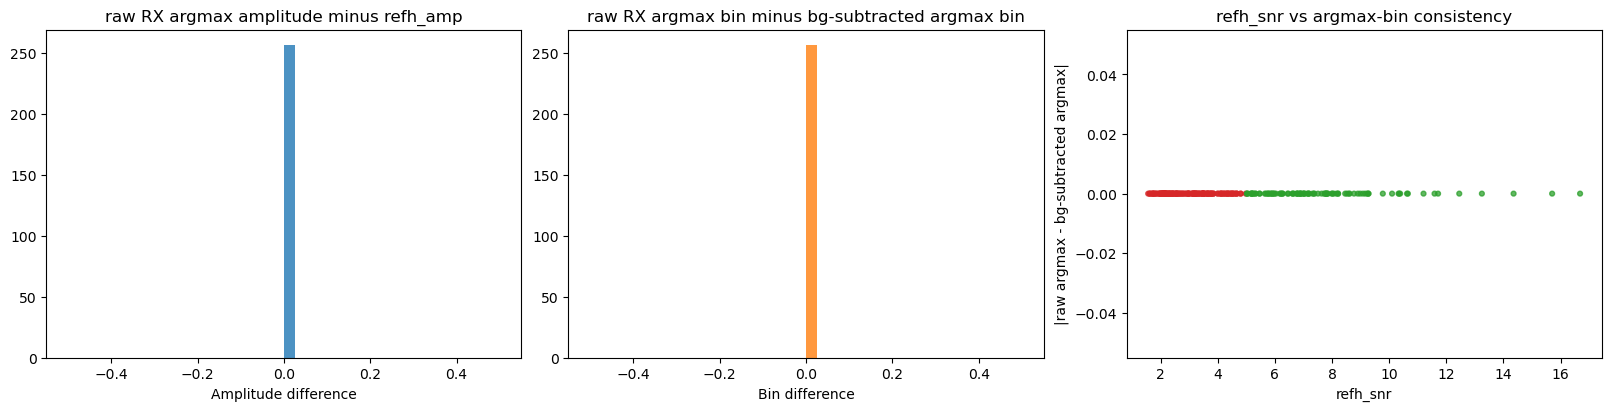

In [3]:
consistency_df = sweep_df.loc[sweep_df["has_waveform"]].copy()
consistency_df["raw_amp_minus_refh_amp"] = (
    consistency_df["raw_rx_argmax_amp_by_track"].astype(float)
    - consistency_df["refh_amp"].astype(float)
)
consistency_df["raw_minus_bgsub_argmax_bin"] = (
    consistency_df["raw_rx_argmax_bin_by_track"].astype(float)
    - consistency_df["bg_subtracted_argmax_bin_by_track"].astype(float)
)
consistency_df["argmax_bin_match_after_bg"] = (
    consistency_df["raw_rx_argmax_bin_by_track"].astype(float)
    == consistency_df["bg_subtracted_argmax_bin_by_track"].astype(float)
)

summary_rows = {
    "raw_amp_minus_refh_amp": consistency_df["raw_amp_minus_refh_amp"].describe(percentiles=[0.05, 0.5, 0.95]),
    "raw_minus_bgsub_argmax_bin": consistency_df["raw_minus_bgsub_argmax_bin"].describe(percentiles=[0.05, 0.5, 0.95]),
}
diagnostic_summary = pd.concat(summary_rows, axis=1)
display(diagnostic_summary)

snr_relation = (
    consistency_df.assign(good_snr=consistency_df["good_snr"].astype(bool))
    .groupby("good_snr")[["refh_snr", "raw_minus_bgsub_argmax_bin"]]
    .agg(["count", "median", "mean"])
)
display(snr_relation)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
axes[0].hist(consistency_df["raw_amp_minus_refh_amp"], bins=40, color="tab:blue", alpha=0.8)
axes[0].set_title("raw RX argmax amplitude minus refh_amp")
axes[0].set_xlabel("Amplitude difference")

axes[1].hist(consistency_df["raw_minus_bgsub_argmax_bin"], bins=40, color="tab:orange", alpha=0.8)
axes[1].set_title("raw RX argmax bin minus bg-subtracted argmax bin")
axes[1].set_xlabel("Bin difference")

axes[2].scatter(
    consistency_df["refh_snr"].astype(float),
    np.abs(consistency_df["raw_minus_bgsub_argmax_bin"].astype(float)),
    c=consistency_df["good_snr"].astype(bool).map({True: "tab:green", False: "tab:red"}),
    s=12,
    alpha=0.75,
)
axes[2].set_title("refh_snr vs argmax-bin consistency")
axes[2].set_xlabel("refh_snr")
axes[2].set_ylabel("|raw argmax - bg-subtracted argmax|")
plt.show()

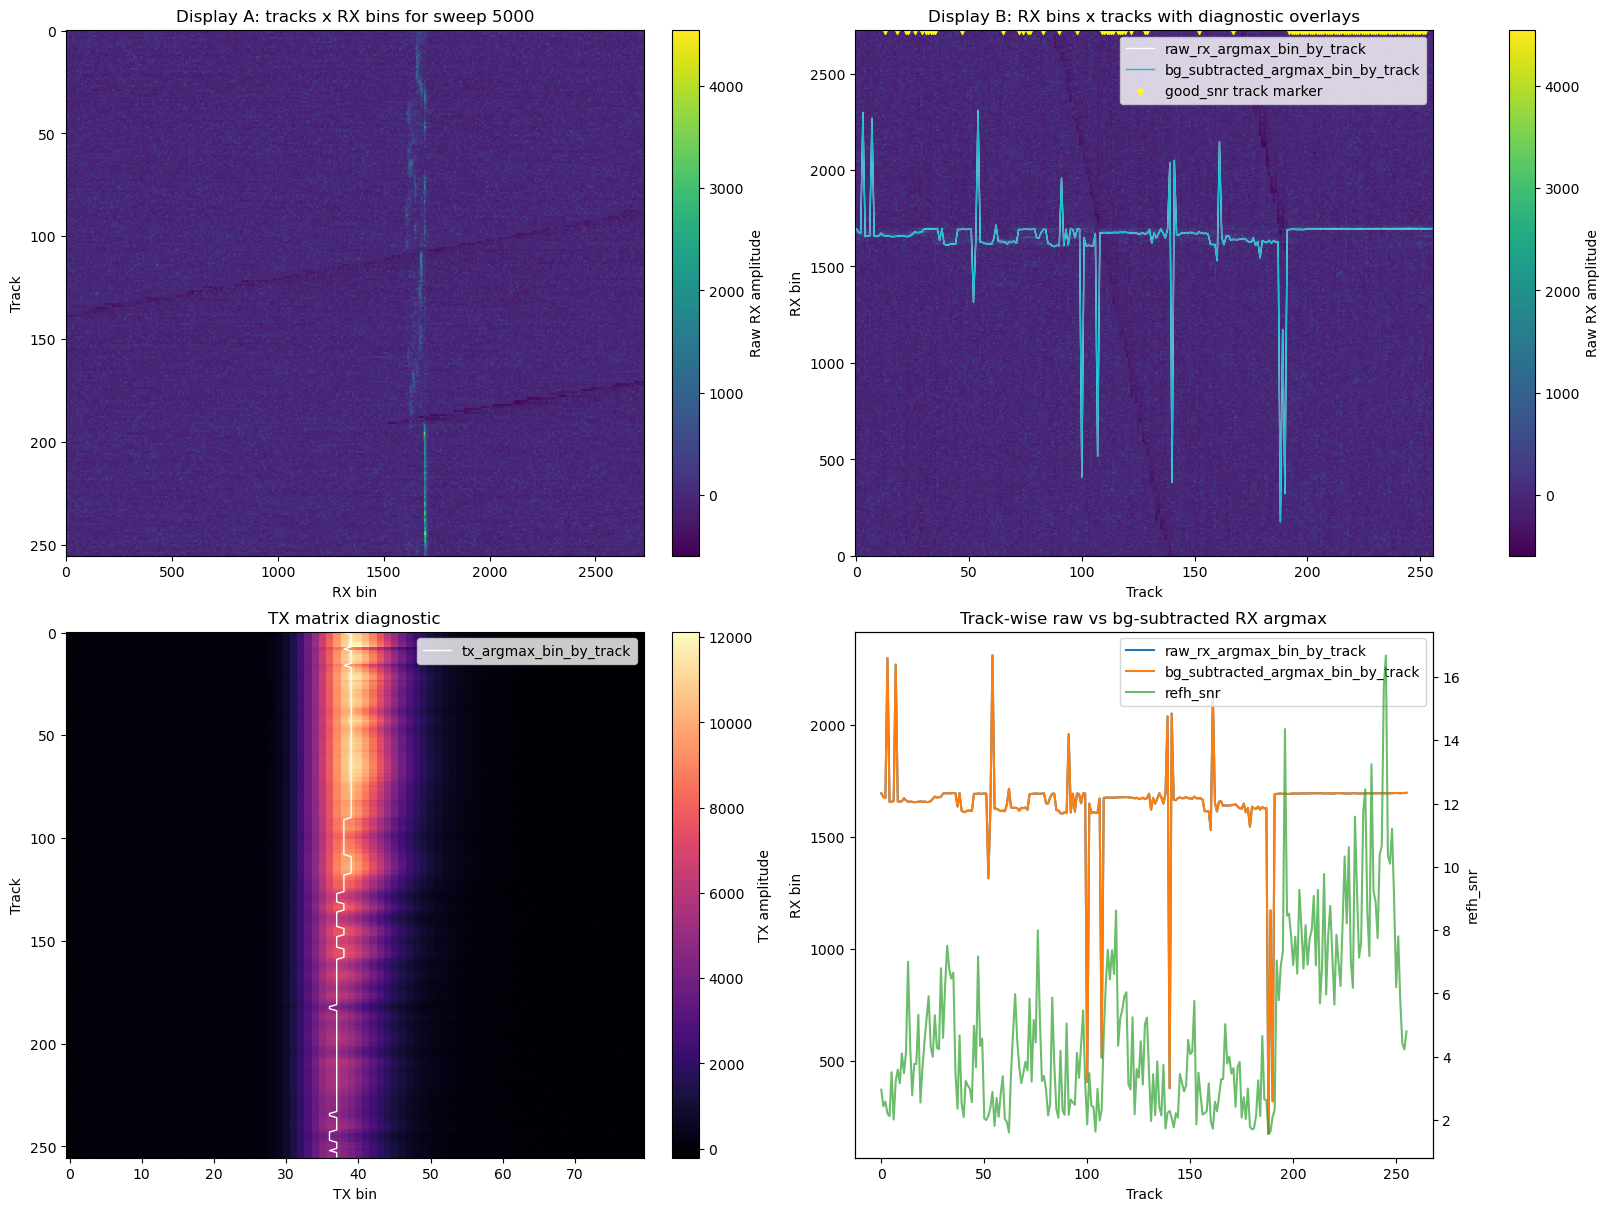

In [4]:
finite_vals = rx_matrix[np.isfinite(rx_matrix)]
display_vmin = float(np.nanmin(finite_vals)) if RX_VMIN is None else float(RX_VMIN)
display_vmax = float(np.nanmax(finite_vals)) if RX_VMAX is None else float(RX_VMAX)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

im = axes[0, 0].imshow(rx_matrix, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0, 0].set_title(f"Display A: tracks x RX bins for sweep {SWEEP_IDX}")
axes[0, 0].set_xlabel("RX bin")
axes[0, 0].set_ylabel("Track")
fig.colorbar(im, ax=axes[0, 0], label="Raw RX amplitude")

im = axes[0, 1].imshow(rx_matrix.T, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
axes[0, 1].plot(selected_tracks, raw_rx_argmax_bin_by_track, color="white", linewidth=1.0, label="raw_rx_argmax_bin_by_track")
axes[0, 1].plot(selected_tracks, bg_subtracted_argmax_bin_by_track, color="tab:cyan", linewidth=1.0, label="bg_subtracted_argmax_bin_by_track")
good_tracks = selected_tracks[sweep_df["good_snr"].astype(bool).to_numpy()]
axes[0, 1].scatter(good_tracks, np.full(good_tracks.size, rx_matrix.shape[1] - 5), marker="v", s=18, color="yellow", label="good_snr track marker")
axes[0, 1].set_title("Display B: RX bins x tracks with diagnostic overlays")
axes[0, 1].set_xlabel("Track")
axes[0, 1].set_ylabel("RX bin")
axes[0, 1].legend(loc="upper right")
fig.colorbar(im, ax=axes[0, 1], label="Raw RX amplitude")

im = axes[1, 0].imshow(tx_matrix, aspect="auto", cmap="magma", interpolation="nearest")
axes[1, 0].plot(tx_argmax_bin_by_track, np.arange(tx_matrix.shape[0]), color="white", linewidth=1.0, label="tx_argmax_bin_by_track")
axes[1, 0].set_title("TX matrix diagnostic")
axes[1, 0].set_xlabel("TX bin")
axes[1, 0].set_ylabel("Track")
axes[1, 0].legend(loc="upper right")
fig.colorbar(im, ax=axes[1, 0], label="TX amplitude")

axes[1, 1].plot(selected_tracks, raw_rx_argmax_bin_by_track, label="raw_rx_argmax_bin_by_track", color="tab:blue")
axes[1, 1].plot(selected_tracks, bg_subtracted_argmax_bin_by_track, label="bg_subtracted_argmax_bin_by_track", color="tab:orange")
axes[1, 1].set_xlabel("Track")
axes[1, 1].set_ylabel("RX bin")
axes[1, 1].set_title("Track-wise raw vs bg-subtracted RX argmax")
ax2 = axes[1, 1].twinx()
ax2.plot(selected_tracks, sweep_df["refh_snr"].astype(float), label="refh_snr", color="tab:green", alpha=0.7)
ax2.set_ylabel("refh_snr")
lines1, labels1 = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1, 1].legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()

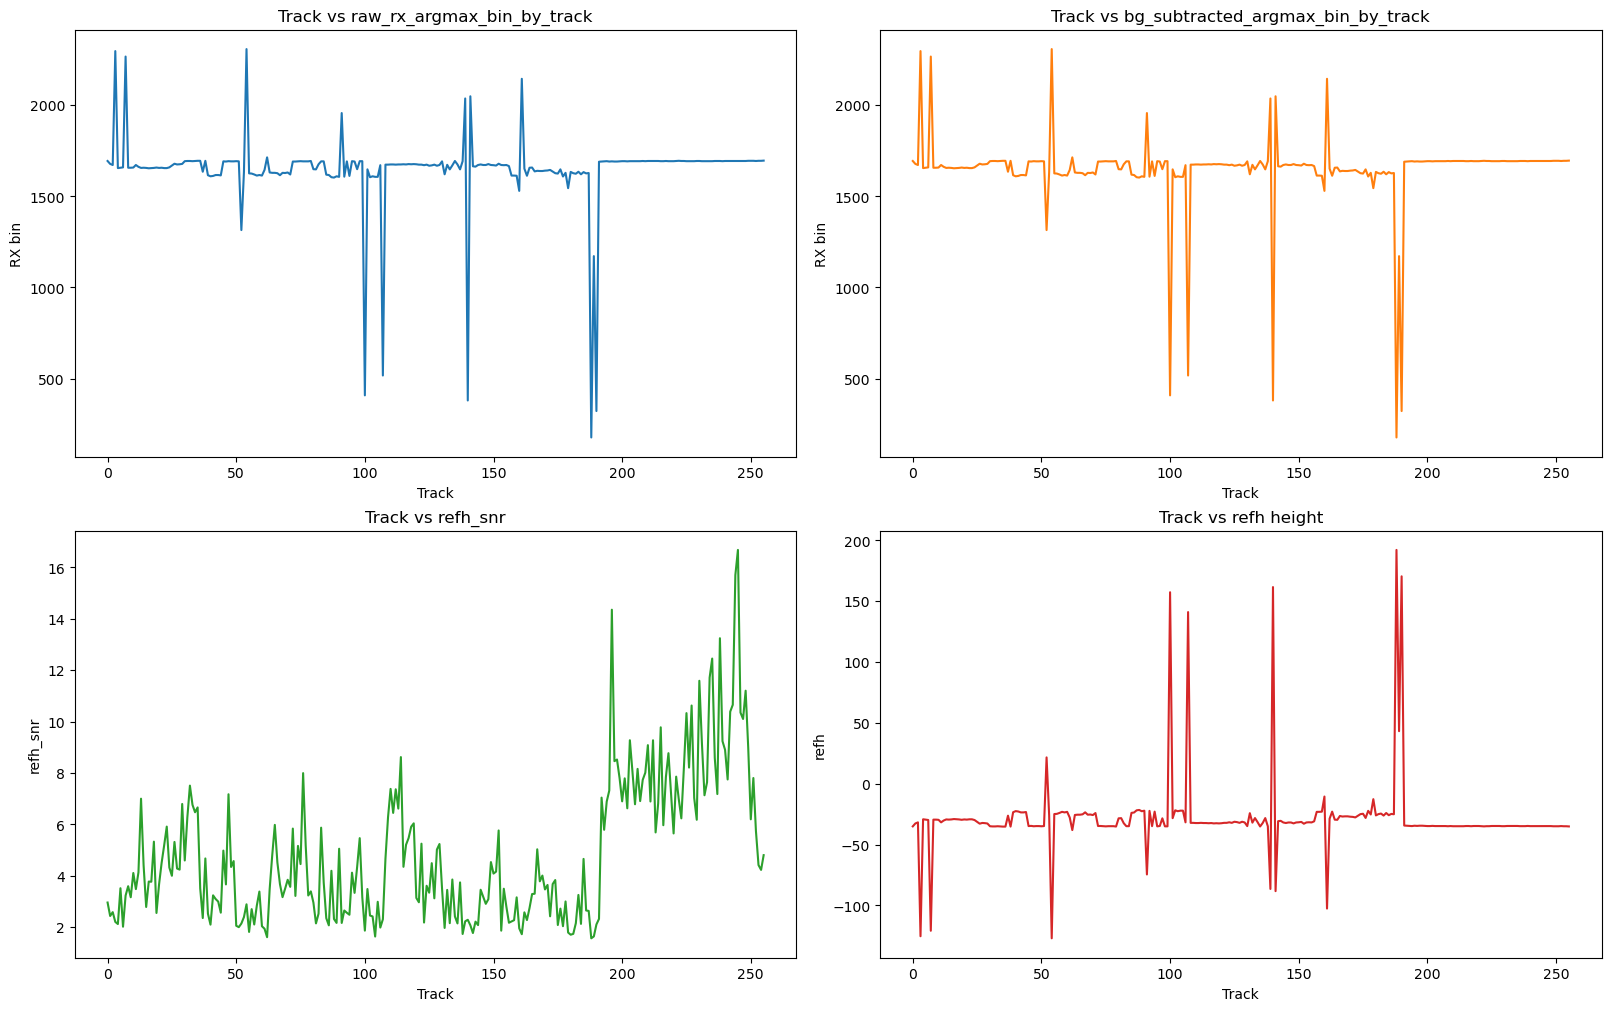

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

axes[0, 0].plot(selected_tracks, raw_rx_argmax_bin_by_track, color="tab:blue")
axes[0, 0].set_title("Track vs raw_rx_argmax_bin_by_track")
axes[0, 0].set_xlabel("Track")
axes[0, 0].set_ylabel("RX bin")

axes[0, 1].plot(selected_tracks, bg_subtracted_argmax_bin_by_track, color="tab:orange")
axes[0, 1].set_title("Track vs bg_subtracted_argmax_bin_by_track")
axes[0, 1].set_xlabel("Track")
axes[0, 1].set_ylabel("RX bin")

axes[1, 0].plot(selected_tracks, sweep_df["refh_snr"].astype(float), color="tab:green")
axes[1, 0].set_title("Track vs refh_snr")
axes[1, 0].set_xlabel("Track")
axes[1, 0].set_ylabel("refh_snr")

axes[1, 1].plot(selected_tracks, sweep_df["refh"].astype(float), color="tab:red")
axes[1, 1].set_title("Track vs refh height")
axes[1, 1].set_xlabel("Track")
axes[1, 1].set_ylabel("refh")

plt.show()